In [ ]:
# question 3 RETAIL SALES PREDICTION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\bits course\assignment 4\q3_retail_promotions.csv")
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


### Dataset Overview

- 1200 records  
- Includes promotions, store type, competition, and sales  
- Target variable: items_sold

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   transaction_date     1200 non-null   str  
 1   store_id             1200 non-null   int64
 2   store_size           1200 non-null   str  
 3   location_type        1200 non-null   str  
 4   promotion_type       1200 non-null   str  
 5   is_weekend           1200 non-null   int64
 6   is_festival          1200 non-null   int64
 7   competition_density  1200 non-null   int64
 8   items_sold           1200 non-null   int64
dtypes: int64(5), str(4)
memory usage: 84.5 KB


In [5]:
df.shape

(1200, 9)

In [6]:
df.describe()

,store_id,is_weekend,is_festival,competition_density,items_sold
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,25.385833,0.280833,0.115833,4.930000,272.564167
std,14.275858,0.449594,0.320158,2.692485,60.142360
min,1.000000,0.000000,0.000000,1.000000,95.000000
25%,13.000000,0.000000,0.000000,3.000000,234.000000
50%,25.000000,0.000000,0.000000,5.000000,271.000000
75%,37.000000,1.000000,0.000000,7.000000,310.000000
max,50.000000,1.000000,1.000000,9.000000,468.000000


In [7]:
df.columns  

Index(['transaction_date', 'store_id', 'store_size', 'location_type',
       'promotion_type', 'is_weekend', 'is_festival', 'competition_density',
       'items_sold'],
      dtype='str')

### Exploratory Data Analysis

- Sales distribution is approximately normal  
- Promotions and store size affect sales  
- Weekend and festival increase demand  
- Competition negatively impacts sales  

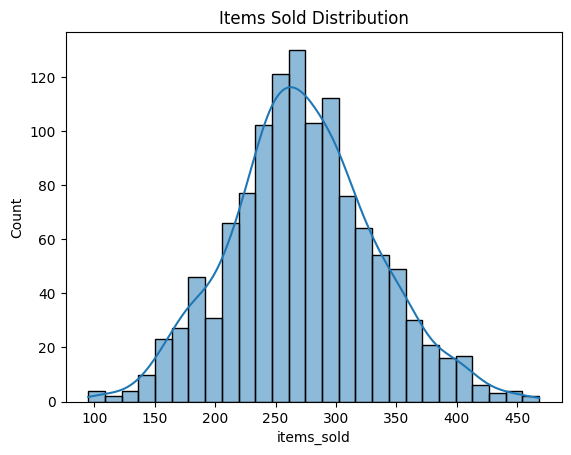

In [8]:
sns.histplot(df['items_sold'], kde=True)
plt.title("Items Sold Distribution")
plt.show()

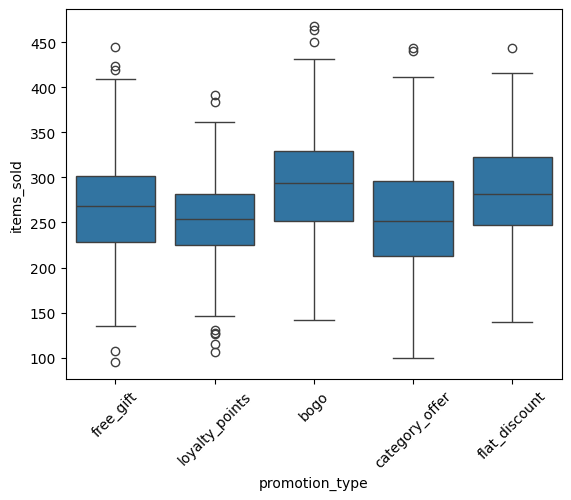

In [9]:
sns.boxplot(x='promotion_type', y='items_sold', data=df)
plt.xticks(rotation=45)
plt.show()

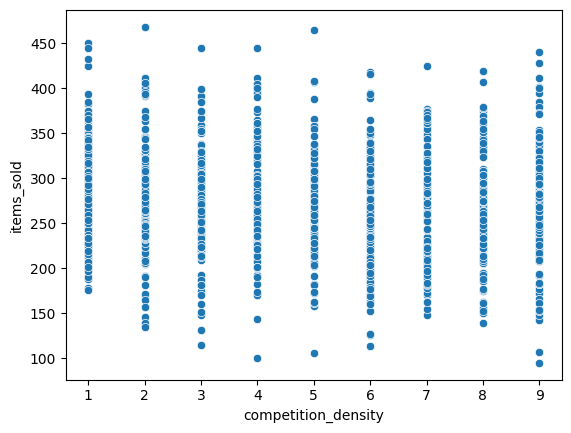

In [10]:
sns.scatterplot(x='competition_density', y='items_sold', data=df)
plt.show()

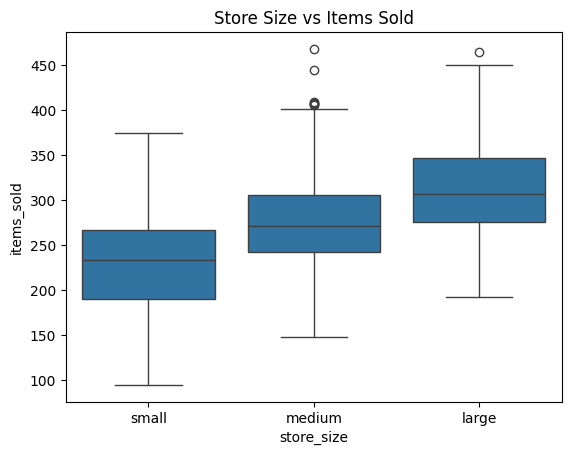

In [11]:
sns.boxplot(x='store_size', y='items_sold', data=df)
plt.title("Store Size vs Items Sold")
plt.show()

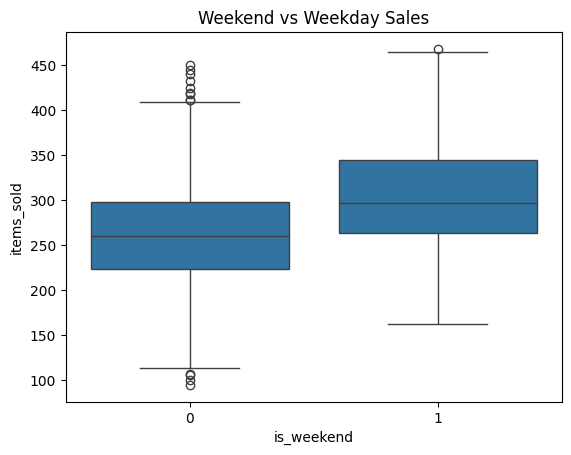

In [12]:
sns.boxplot(x='is_weekend', y='items_sold', data=df)
plt.title("Weekend vs Weekday Sales")
plt.show()

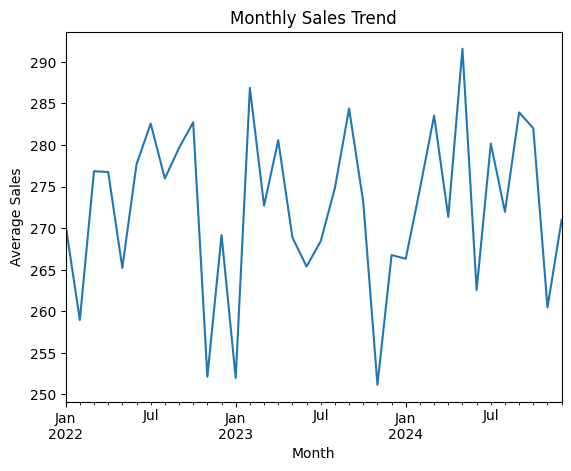

In [14]:
df['month'] = pd.to_datetime(df['transaction_date']).dt.to_period('M')
df.groupby('month')['items_sold'].mean().plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

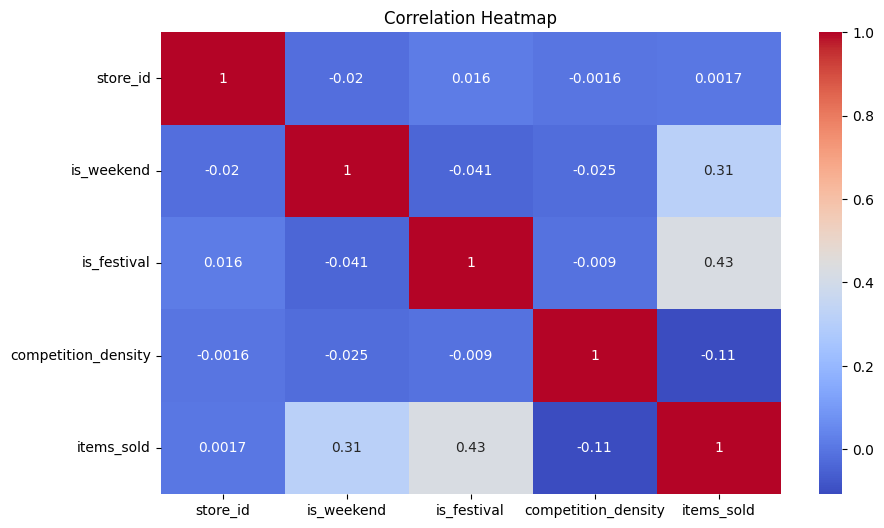

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

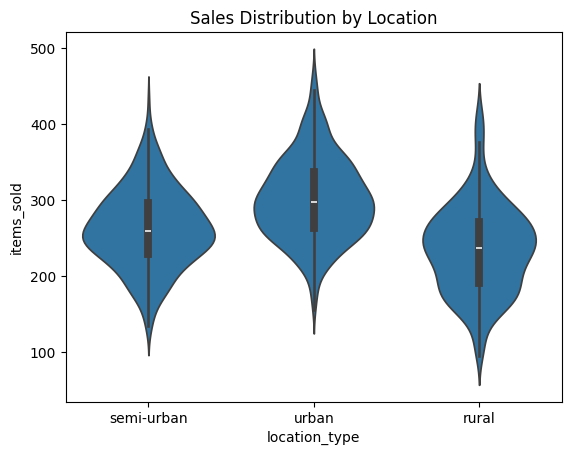

In [17]:
sns.violinplot(x='location_type', y='items_sold', data=df)
plt.title("Sales Distribution by Location")
plt.show()

### Feature Engineering

- Extracted year, month, day_of_week  
- Created is_month_end feature  
- Helps capture seasonality

In [18]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

### Outlier Treatment

- IQR method used  
- Outliers replaced with median  
- Preserves dataset size and stability

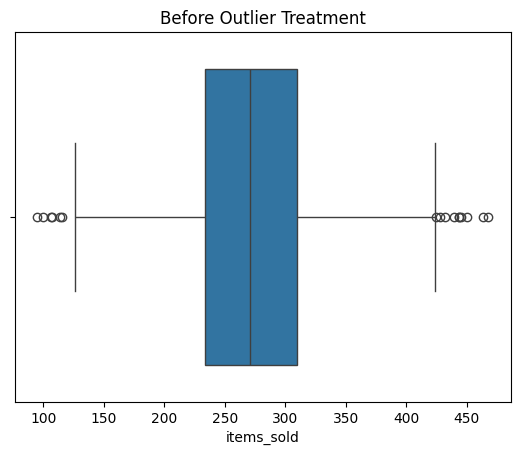

In [19]:
sns.boxplot(x=df['items_sold'])
plt.title("Before Outlier Treatment")
plt.show()

In [20]:
Q1 = df['items_sold'].quantile(0.25)
Q3 = df['items_sold'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

120.0 424.0


In [21]:
median_val = df['items_sold'].median()

df['items_sold'] = np.where(df['items_sold'] > upper, median_val, df['items_sold'])
df['items_sold'] = np.where(df['items_sold'] < lower, median_val, df['items_sold'])

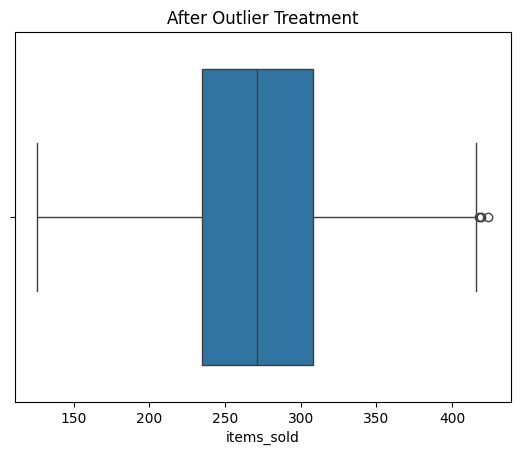

In [22]:
sns.boxplot(x=df['items_sold'])
plt.title("After Outlier Treatment")
plt.show()

### Train-Test Split (80–20 Time-Based)

- Data sorted by transaction_date  
- First 80% → training  
- Last 20% → testing  
- Prevents data leakage

In [23]:
df = df.sort_values('transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print(train.shape, test.shape)

(960, 13) (240, 13)


In [24]:
print("Train dates:", train['transaction_date'].min(), "-", train['transaction_date'].max())
print("Test dates:", test['transaction_date'].min(), "-", test['transaction_date'].max())

Train dates: 2022-01-01 00:00:00 - 2024-06-11 00:00:00
Test dates: 2024-06-12 00:00:00 - 2024-12-31 00:00:00


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ['competition_density','year','month','day_of_week','is_month_end']
cat_cols = ['promotion_type','location_type','store_size']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

In [26]:
X_train = train.drop(['items_sold','transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold','transaction_date'], axis=1)
y_test = test['items_sold']

### Models Used

- Linear Regression  
- Ridge Regression (L2)  
- Lasso Regression (L1)  
- Random Forest

### Regularization Tuning

- Multiple alpha values tested  
- Best alpha selected using lowest test RMSE  

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = Pipeline([
    ('pre', preprocessor),
    ('model', LinearRegression())
])

lr.fit(X_train, y_train)

lr_train = lr.predict(X_train)
lr_test = lr.predict(X_test)

print("Linear Regression")
print("Linear Regression")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, lr_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, lr_test)))
print("MAE:", mean_absolute_error(y_test, lr_test))
print("R2:", r2_score(y_test, lr_test))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, lr_test)))
print("MAE:", mean_absolute_error(y_test, lr_test))
print("R2:", r2_score(y_test, lr_test))

Linear Regression
Linear Regression
Train RMSE: 38.95573442309105
Test RMSE: 39.35907208023145
MAE: 29.553928627315447
R2: 0.5371946301782162
Test RMSE: 39.35907208023145
MAE: 29.553928627315447
R2: 0.5371946301782162


In [36]:
from sklearn.linear_model import Lasso

lasso_alphas = [0.001, 0.01, 0.1, 1, 10]

lasso_results = []

for alpha in lasso_alphas:
    
    lasso = Pipeline([
        ('pre', preprocessor),
        ('model', Lasso(alpha=alpha))
    ])
    
    lasso.fit(X_train, y_train)
    
    train_pred = lasso.predict(X_train)
    test_pred = lasso.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    lasso_results.append((alpha, train_rmse, test_rmse))
    
    print(f"Alpha={alpha}")
    print("Train RMSE:", train_rmse)
    print("Test RMSE:", test_rmse)
    print("-"*30)
    print("MAE:", mean_absolute_error(y_test, test_pred))
    print("R2:", r2_score(y_test, test_pred))

Alpha=0.001
Train RMSE: 38.955736418169515
Test RMSE: 39.36068091917895
------------------------------
MAE: 29.55648569218929
R2: 0.5371567941987374
Alpha=0.01
Train RMSE: 38.955933991392996
Test RMSE: 39.37534738579374
------------------------------
MAE: 29.579504132598345
R2: 0.5368118032595001
Alpha=0.1
Train RMSE: 38.97551636616534
Test RMSE: 39.53940455715418
------------------------------
MAE: 29.826382992383092
R2: 0.5329440202420499
Alpha=1
Train RMSE: 40.116447193552226
Test RMSE: 41.2054662737418
------------------------------
MAE: 31.737795574451948
R2: 0.4927543246775301
Alpha=10
Train RMSE: 54.6924602913026
Test RMSE: 56.03465243233515
------------------------------
MAE: 43.97325906027138
R2: 0.06195850072415898


In [38]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

ridge_alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []

for alpha in ridge_alphas:
    
    ridge = Pipeline([
        ('pre', preprocessor),
        ('model', Ridge(alpha=alpha))
    ])
    
    ridge.fit(X_train, y_train)
    
    train_pred = ridge.predict(X_train)
    test_pred = ridge.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    ridge_results.append((alpha, train_rmse, test_rmse))
    
    print(f"Alpha={alpha}")
    print("Train RMSE:", train_rmse)
    print("Test RMSE:", test_rmse)
    print("-"*30)
    print("MAE:", mean_absolute_error(y_test, test_pred))
    print("R2:", r2_score(y_test, test_pred))

Alpha=0.01
Train RMSE: 38.955734660143236
Test RMSE: 39.359527057160896
------------------------------
MAE: 29.55451907837788
R2: 0.537183930384141
Alpha=0.1
Train RMSE: 38.95575805630133
Test RMSE: 39.363634397274225
------------------------------
MAE: 29.559819243276237
R2: 0.5370873315509815
Alpha=1
Train RMSE: 38.95802776528593
Test RMSE: 39.4058959392346
------------------------------
MAE: 29.613195854214936
R2: 0.5360928143890846
Alpha=10
Train RMSE: 39.130832632404775
Test RMSE: 39.90697435373822
------------------------------
MAE: 30.182418792053518
R2: 0.5242198805199767
Alpha=100
Train RMSE: 42.86587115855104
Test RMSE: 44.53664063050754
------------------------------
MAE: 34.62811166090252
R2: 0.4074246277910889


In [39]:
best_ridge = min(ridge_results, key=lambda x: x[2])
best_lasso = min(lasso_results, key=lambda x: x[2])

print("Best Ridge Alpha:", best_ridge)
print("Best Lasso Alpha:", best_lasso)

Best Ridge Alpha: (0.01, np.float64(38.955734660143236), np.float64(39.359527057160896))
Best Lasso Alpha: (0.001, np.float64(38.955736418169515), np.float64(39.36068091917895))


In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf.fit(X_train, y_train)

rf_train = rf.predict(X_train)
rf_test = rf.predict(X_test)

print("Random Forest")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, rf_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, rf_test)))
print("MAE:", mean_absolute_error(y_test, rf_test))
print("R2:", r2_score(y_test, rf_test))

Random Forest
Train RMSE: 15.509784697545198
Test RMSE: 42.91722592202494
MAE: 35.03554583333334
R2: 0.44973489636859243


In [44]:
print("RF Train RMSE:", np.sqrt(mean_squared_error(y_train, rf_train)))
print("RF Test RMSE:", np.sqrt(mean_squared_error(y_test, rf_test)))

RF Train RMSE: 15.509784697545198
RF Test RMSE: 42.91722592202494


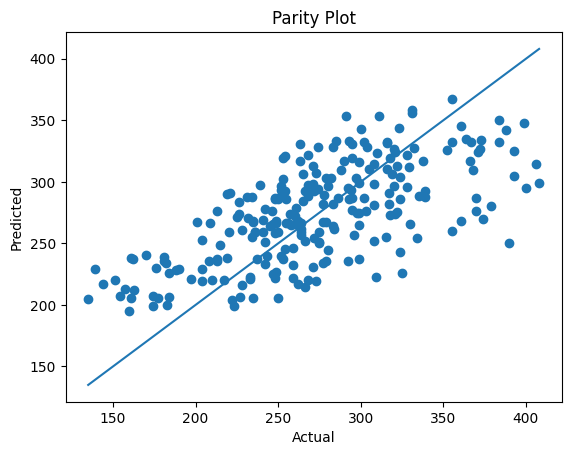

In [45]:
plt.scatter(y_test, rf_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot")
plt.show()

In [46]:
ohe_features = rf.named_steps['pre']\
    .named_transformers_['cat']\
    .get_feature_names_out(cat_cols)

features = num_cols + list(ohe_features)

importances = rf.named_steps['model'].feature_importances_

pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

,Feature,Importance
3,day_of_week,0.183002
12,store_size_small,0.173700
10,location_type_urban,0.134251
2,month,0.119801
0,competition_density,0.115251
11,store_size_medium,0.060722
1,year,0.048655
9,location_type_semi-urban,0.034834
8,promotion_type_loyalty_points,0.032941
5,promotion_type_category_offer,0.031401


### Evaluation Metrics

- RMSE → error measure  
- MAE → average error  
- R² → model performance  

In [49]:
results = []

def evaluate_model(name, model):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_rmse = mean_squared_error(y_train, train_pred, squared=False)
    test_rmse = mean_squared_error(y_test, test_pred, squared=False)
    mae = mean_absolute_error(y_test, test_pred)
    r2 = r2_score(y_test, test_pred)
    
    results.append([name, train_rmse, test_rmse, mae, r2])


# Evaluate all models
def evaluate_model(name, model):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    mae = mean_absolute_error(y_test, test_pred)
    r2 = r2_score(y_test, test_pred)
    
    results.append([name, train_rmse, test_rmse, mae, r2])
evaluate_model("Ridge", ridge)
evaluate_model("Lasso", lasso)
evaluate_model("Random Forest", rf)

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=[
    "Model", "Train RMSE", "Test RMSE", "MAE", "R2"
])

results_df

,Model,Train RMSE,Test RMSE,MAE,R2
0,Ridge,42.865871,44.536641,34.628112,0.407425
1,Lasso,54.692460,56.034652,43.973259,0.061959
2,Random Forest,15.509785,42.917226,35.035546,0.449735


### Best Model

- Random Forest performed best  
- Handles non-linear relationships  
- Lower test RMSE and better generalization

In [50]:
results_df.sort_values(by="Test RMSE")

,Model,Train RMSE,Test RMSE,MAE,R2
2,Random Forest,15.509785,42.917226,35.035546,0.449735
0,Ridge,42.865871,44.536641,34.628112,0.407425
1,Lasso,54.692460,56.034652,43.973259,0.061959


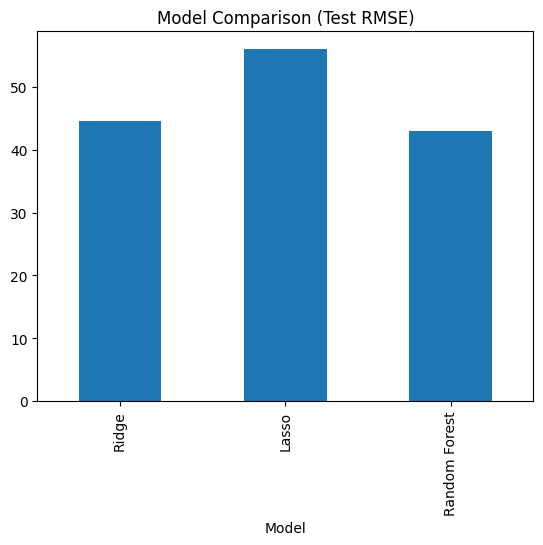

In [51]:
results_df.set_index("Model")["Test RMSE"].plot(kind="bar")
plt.title("Model Comparison (Test RMSE)")
plt.show()

### Conclusion

- Sales influenced by promotions, time, and competition  
- Tree-based models outperform linear models  